# KNN Exercise

![iris](images/iris.jpg)

We are going to use the famous **iris data set** again. 

The dataset consists of four attributes, which can be used to distinguish different iris species: 
* sepal-width
* sepal-length
* petal-width 
* petal-length. 


The task is to predict the class to which these plants belong. There are three classes in the dataset: **Iris-setosa, Iris-versicolor and Iris-virginica.** 

Further details of the dataset are available here.
https://scikit-learn.org/stable/auto_examples/datasets/plot_iris_dataset.html

## Task

1. Please import and pre-process the data (as far as it's necessary). Afterwards split it in a train and test set, fit a KNN model and make predictions on the test set. The last step is to evaluate your model. Try to also scale your data and fit the model to the unscaled and scaled data. Can you see a difference in performance? 
If you can't it's because the original features are all on a very similar scale. Try multiplying one of the features by a factor of 10 and fitting the model to unscaled and scaled data. The difference should now be obvious 

In [1]:
import numpy as np
import pandas as pd

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Load dataset
data = load_iris()
X = data.data
y = data.target

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [3]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)
accuracy_unscaled = accuracy_score(y_test, y_pred)

print("Accuracy (unscaled):", accuracy_unscaled)

Accuracy (unscaled): 1.0


In [ ]:
#we’ll likely see very similar performance.
#Because all features are already on similar scales (cm measurements).

In [2]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

knn_scaled = KNeighborsClassifier(n_neighbors=5)
knn_scaled.fit(X_train_scaled, y_train)

y_pred_scaled = knn_scaled.predict(X_test_scaled)
accuracy_scaled = accuracy_score(y_test, y_pred_scaled)

print("Accuracy (scaled):", accuracy_scaled)

Accuracy (scaled): 1.0


In [4]:
X_modified = X.copy()
X_modified[:, 0] = X_modified[:, 0] * 10  # multiply first feature by 10

# Split again
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_modified, y, test_size=0.2, random_state=42
)

In [5]:
knn_m = KNeighborsClassifier(n_neighbors=5)
knn_m.fit(X_train_m, y_train_m)

y_pred_m = knn_m.predict(X_test_m)
accuracy_unscaled_modified = accuracy_score(y_test_m, y_pred_m)

print("Accuracy (unscaled, modified):", accuracy_unscaled_modified)

Accuracy (unscaled, modified): 0.9666666666666667


In [6]:
scaler_m = StandardScaler()

X_train_m_scaled = scaler_m.fit_transform(X_train_m)
X_test_m_scaled = scaler_m.transform(X_test_m)

knn_m_scaled = KNeighborsClassifier(n_neighbors=5)
knn_m_scaled.fit(X_train_m_scaled, y_train_m)

y_pred_m_scaled = knn_m_scaled.predict(X_test_m_scaled)
accuracy_scaled_modified = accuracy_score(y_test_m, y_pred_m_scaled)

print("Accuracy (scaled, modified):", accuracy_scaled_modified)

Accuracy (scaled, modified): 1.0


2. Please also calculate the accuracy for K values of 1 to 40. In each iteration the accuracy for the predicted values of the test set is calculated and the result is appended to an error list.
The next step is to plot the accuracy values against K values.

In [7]:
import matplotlib.pyplot as plt

accuracies = []

k_values = range(1, 41)

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    
    y_pred = knn.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    
    accuracies.append(acc)

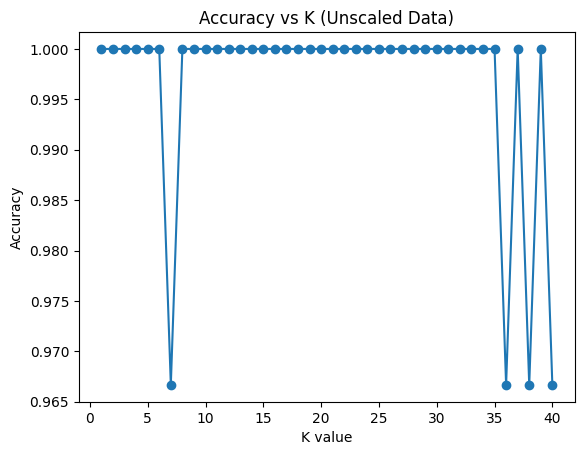

In [8]:
plt.figure()
plt.plot(k_values, accuracies, marker='o')
plt.xlabel("K value")
plt.ylabel("Accuracy")
plt.title("Accuracy vs K (Unscaled Data)")
plt.show()

In [9]:
accuracies_scaled = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    
    y_pred = knn.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    
    accuracies_scaled.append(acc)

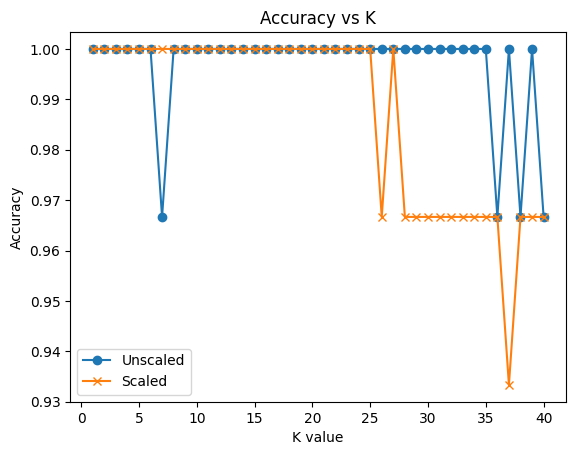

In [10]:
plt.figure()
plt.plot(k_values, accuracies, marker='o', label='Unscaled')
plt.plot(k_values, accuracies_scaled, marker='x', label='Scaled')
plt.xlabel("K value")
plt.ylabel("Accuracy")
plt.title("Accuracy vs K")
plt.legend()
plt.show()

High Bias (Underfitting): As K gets too large, the model becomes too "blunt". Instead of looking at the specific neighborhood, it starts looking at a huge chunk of the dataset. 